**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [2]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [26]:
import numpy as np

def averaging_filter(x, N):
    """
    Applies an N-point averaging filter to the input signal x.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The filtered output signal
    """

    b = np.ones(N) / N
    y = np.convolve(x, b, mode='same') 

    return y



1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

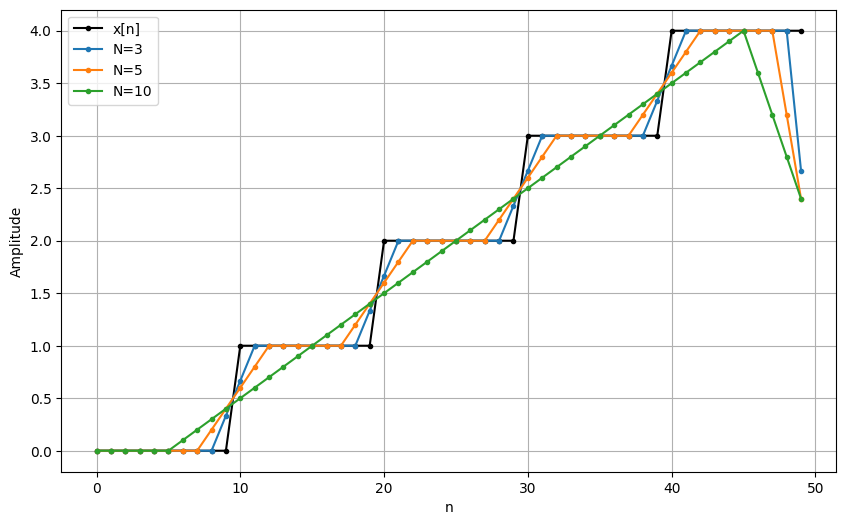

In [27]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([np.floor(i / 10) for i in range(50)])  # esglaons de 10 mostres
Ns = [3, 5, 10]

fs = 1

plt.figure(figsize=(10, 6))
plt.plot(x, 'k.-', label='x[n]')

for N in Ns:
    y = averaging_filter(x, N)
    plt.plot(y, '.-', label=f'N={N}')


plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


We observe when the N is bigger, the more the filter smooths the signal. This happens because each point is the average of many samples. That's why for a small N, the output shows sharp transitions, because the filter only uses a few points to compute the average.

1.4 How would you classify this filter, as a low-pass o high-pass filter?

The averaging filter is classified as a low-pass filter because it smooths the input signal by averaging each sample with samples surrounding each one, which reduces rapid changes and preserves only the slow variations.




---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

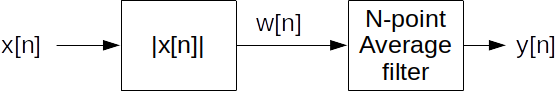

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [6]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating 
    a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    x_rectified = np.abs(x)
    b = np.ones(N) / N
    y = np.convolve(x_rectified, b, mode='same')

    return y

2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

fatal: destination path 'sis1-group202' already exists and is not an empty directory.


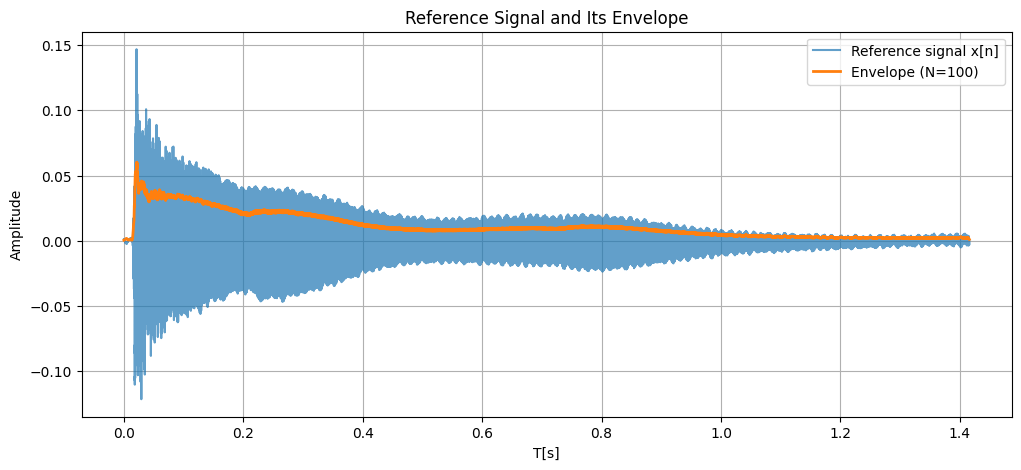

In [20]:
!git clone https://github.com/davidperaltaf/sis1-group202
filepath = "./sis1-group202/labs/audio/sound.wav"
ref, fs = load_audio(filepath)

N = 100
env = envelope(ref, N)

t = np.arange(len(ref)) / fs

plt.figure(figsize=(12, 5))
plt.plot(t, ref, label="Reference signal x[n]", alpha=0.7)
plt.plot(t, env, label=f"Envelope (N={N})", linewidth=2)
plt.xlabel("T[s]")
plt.ylabel("Amplitude")
plt.title("Reference Signal and Its Envelope")
plt.legend()
plt.grid(True)
plt.show()

2.3 Change the number N to get a good result. What happens when you change the number N?

When you increase the number N the envelope seems to be less similar than the reference signal and when you decrease it, it seems to be more similar.

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

This system extracts the envelope because the rectified signal w[n] contains both the rapid oscillations of the original waveform and the slow variations that form its amplitude outline. When we apply the averaging filter to w[n], the fast oscillations are smoothed out while the slower amplitude changes remain. As a result, y[n] follows only the gradual variations in amplitude, which is exactly the envelope.

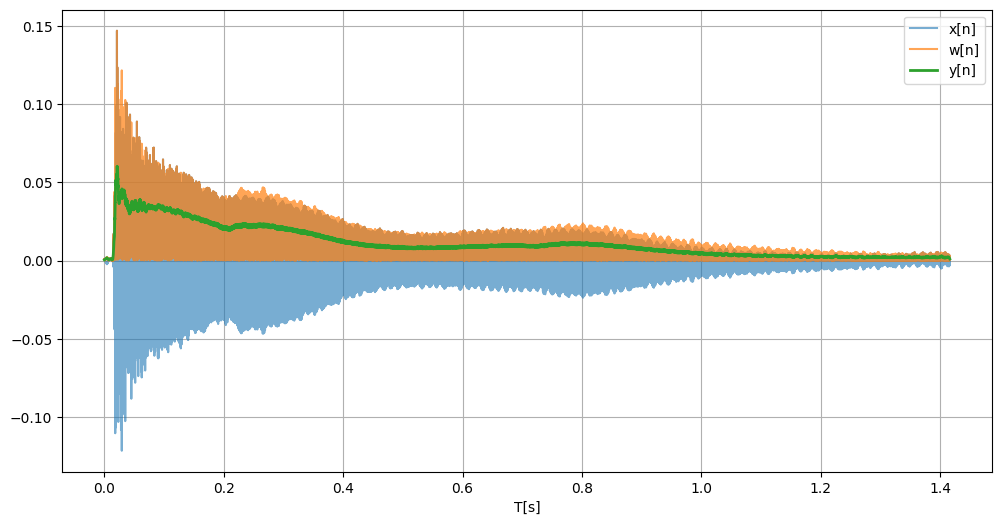

In [19]:
x = ref  
N = 100

w = np.abs(x)
y = envelope(x, N)

t = np.arange(len(x)) / fs

plt.figure(figsize=(12,6))
plt.plot(t, x, label='x[n]', alpha=0.6)
plt.plot(t, w, label='w[n]', alpha=0.7)
plt.plot(t, y, label=f'y[n]', linewidth=2)
plt.legend()
plt.xlabel("T[s]")
plt.grid()
plt.show()

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

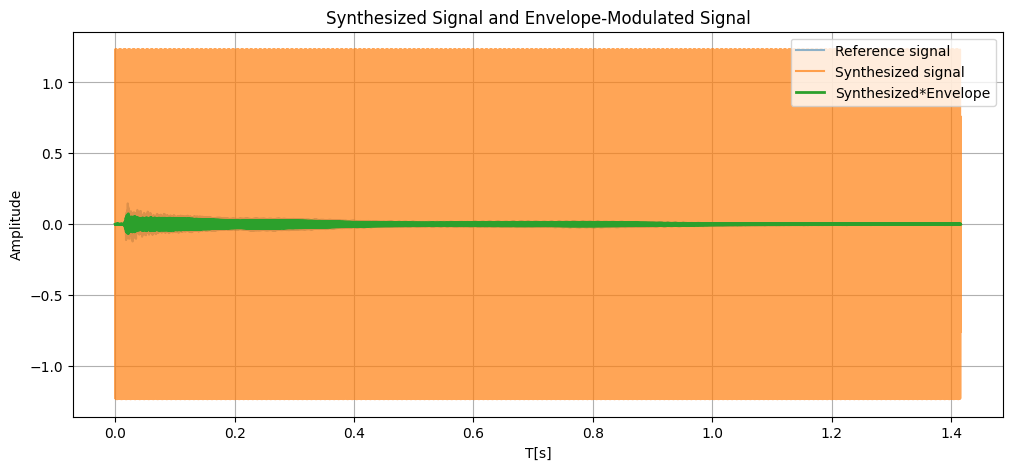

In [18]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

t = np.arange(len(env)) / fs
weights = [0.2762002, 1, 0.06239747, 0.009533455, 0.002722459, 0.002277515, 0.001047189]

phi = 0
f0 = 776 

syn = synthesize(f0, phi, weights, t)
syn_env = syn * env

plt.figure(figsize=(12,5))
plt.plot(t, ref[:len(t)], label="Reference signal", alpha=0.5)
plt.plot(t, syn, label="Synthesized signal", alpha=0.7)
plt.plot(t, syn_env, label="Synthesized*Envelope", linewidth=2)
plt.xlabel("T[s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.title("Synthesized Signal and Envelope-Modulated Signal")
plt.show()

2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

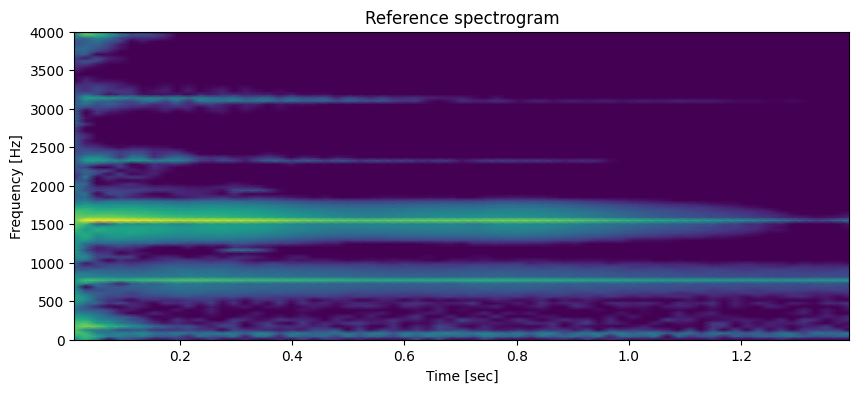

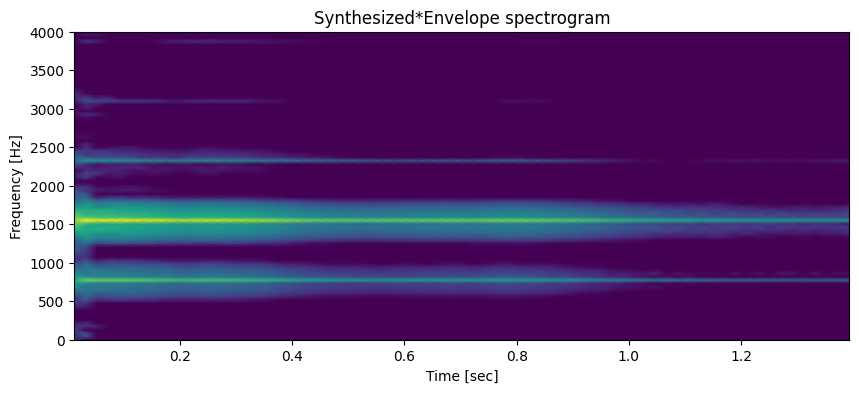

In [17]:
from scipy.signal import spectrogram

nperseg = 1024

ff, tt, S_ref = spectrogram(ref, fs, nperseg=nperseg)
_,  _, S_synt = spectrogram(syn_env, fs, nperseg=nperseg)

plt.figure(figsize=(10,4))
plot_spectrogram(ff, tt, S_ref)
plt.title("Reference spectrogram")
plt.ylim([0, 4000])
plt.show()

plt.figure(figsize=(10,4))
plot_spectrogram(ff, tt, S_synt)
plt.title("Synthesized*Envelope spectrogram")
plt.ylim([0, 4000])
plt.show()

The main difference is that the synthesized spectogram appears to show much less noise than the reference spectogram. Nonetheless, they show the same pattern.

2.7 Listen to the synthesized signal and compare it to the reference.



In [21]:
from IPython.display import Audio

print("Reference:")
display(Audio(ref, rate=fs))

print("Synthesized*Envelope:")
display(Audio(syn_env, rate=fs))


Reference:


Synthesized*Envelope:
